# DenseNet-121 KL Grading Reproduction

## Configuration Summary

| Item | Configuration |
| --- | --- |
| Task | Five-class Kellgren-Lawrence grade classification (0-4) |
| Backbone | ImageNet-pretrained DenseNet-121 |
| Classifier head | Flattened convolutional features -> 128 -> 64 -> 16 -> 5; ReLU and Dropout(0.30) after hidden layers |
| Input | Grayscale converted to 3 channels, 224 x 224 |
| Preprocessing | Resize; optional Otsu threshold plus morphological opening; no center crop; tensor normalization to [-1, 1] |
| Augmentation | Rotation +/-30 degrees, affine translation +/-10%, scale 0.8-1.2, shear +/-20 degrees, horizontal flip |
| Loss | Categorical cross-entropy |
| Optimizer | Adam, learning rate 1e-4, weight decay 1e-4 |
| Schedule | ReduceLROnPlateau, factor 0.1, patience 3 |
| Stopping | Early stopping after 8 validation-loss epochs without improvement |
| Split | Stratified 80% development / 20% test, then 90% train / 10% validation |
| Explainability | Post-hoc Grad-CAM from DenseNet `features.norm5` |

This follows the DenseNet-121 KL-grading paper recipe where specified. The paper used a different 301-patient dataset; this run uses the local KL image dataset, so published scores are not expected to match. Values not specified by the paper are explicit experiment choices.

Run all cells top to bottom in a fresh Colab GPU runtime. The final sections display the metric dashboard and one Grad-CAM example for each true KL grade.


In [1]:
!pip -q install timm scikit-learn opencv-python-headless


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import copy
import json
import matplotlib.pyplot as plt
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

SEED = 42
DATA_ROOT = Path('/content/drive/MyDrive/Datasets/KneeXrayData_Mendeley_v1/extracted/KneeXrayData/ClsKLData/kneeKL224')
RUN_DIR = Path('/content/drive/MyDrive/Models/paper_fmed_densenet121') / pd.Timestamp.utcnow().strftime('%Y-%m-%d_%H-%M-%S_UTC')
INPUT_SIZE = 224
BATCH_SIZE = 32                         # not reported by the paper
MAX_EPOCHS = 50                         # early stopping controls the final epoch
LEARNING_RATE = 1e-4                    # paper says reduced LR but gives no value
WEIGHT_DECAY = 1e-4                     # paper: L2 lambda = 1e-4
EARLY_STOPPING_PATIENCE = 8
USE_PAPER_MORPHOLOGY = True             # Otsu + opening described in the paper

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Kaggle/224 dataset not found: {DATA_ROOT}')
RUN_DIR.mkdir(parents=True, exist_ok=False)
print('Device:', DEVICE)
print('Run directory:', RUN_DIR)


Mounted at /content/drive
Device: cuda
Run directory: /content/drive/MyDrive/Models/paper_fmed_densenet121/2026-08-09_06-49-52_UTC


## Paper preprocessing and augmentation

The source paper describes resizing to 224, grayscale conversion, Otsu thresholding with morphological opening, zero-padding, and normalization to [0, 1]. Training augmentation is rotation up to +/-30 degrees, zoom 0.8-1.2, affine translation up to 10%, shear up to +/-20 degrees, and horizontal flipping. The test split is created before augmentation.

The repository safeguard against destructive center crops is respected: padding and affine transforms preserve marginal anatomy.


In [3]:
def paper_preprocess(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise RuntimeError(f'Cannot decode {path}')
    image = cv2.resize(image, (INPUT_SIZE, INPUT_SIZE), interpolation=cv2.INTER_AREA)
    if USE_PAPER_MORPHOLOGY:
        _, mask = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        kernel = np.ones((3, 3), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        image = cv2.bitwise_and(image, image, mask=mask)
    return cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

def pad_to_square(image):
    h, w = image.shape[:2]
    side = max(h, w)
    top, left = (side - h) // 2, (side - w) // 2
    return cv2.copyMakeBorder(image, top, side-h-top, left, side-w-left, cv2.BORDER_CONSTANT, value=(0, 0, 0))

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=0, translate=(0.10, 0.10), scale=(0.8, 1.2), shear=20),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3),
])
eval_transform = transforms.Compose([
    transforms.ToPILImage(), transforms.ToTensor(), transforms.Normalize([0.5] * 3, [0.5] * 3),
])

records = []
for path in sorted(DATA_ROOT.glob('*/*/*.png')):
    try:
        grade = int(path.parent.name)
    except ValueError:
        continue
    if grade in range(5): records.append({'path': str(path), 'grade': grade})
frame = pd.DataFrame(records)
if frame.empty:
    raise RuntimeError(f'No grade/PNG files found below {DATA_ROOT}')
development, test = train_test_split(frame, test_size=0.20, random_state=SEED, stratify=frame.grade)
train_frame, val_frame = train_test_split(development, test_size=0.10, random_state=SEED, stratify=development.grade)
print('split sizes:', len(train_frame), len(val_frame), len(test))

class KneeDataset(Dataset):
    def __init__(self, rows, transform): self.rows = rows.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.rows)
    def __getitem__(self, index):
        row = self.rows.iloc[index]
        return self.transform(paper_preprocess(row.path)), int(row.grade)

train_loader = DataLoader(KneeDataset(train_frame, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(KneeDataset(val_frame, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(KneeDataset(test, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


split sizes: 7045 783 1958


In [4]:
from sklearn.metrics import average_precision_score, cohen_kappa_score, precision_recall_fscore_support


class PaperDenseNet121(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('densenet121', pretrained=True, num_classes=0, global_pool='')
        with torch.no_grad():
            feature_shape = self.backbone(torch.zeros(1, 3, INPUT_SIZE, INPUT_SIZE)).shape
        flattened = int(np.prod(feature_shape[1:]))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened, 128), nn.ReLU(), nn.Dropout(0.30),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.30),
            nn.Linear(64, 16), nn.ReLU(), nn.Dropout(0.30),
            nn.Linear(16, 5),
        )

    def forward(self, images):
        return self.head(self.backbone(images))


model = PaperDenseNet121().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
criterion = nn.CrossEntropyLoss()


def evaluate(loader):
    model.eval(); losses=[]; labels=[]; probabilities=[]
    with torch.no_grad():
        for images, target in loader:
            images, target = images.to(DEVICE, non_blocking=True), target.to(DEVICE, non_blocking=True)
            logits = model(images)
            losses.append(float(criterion(logits, target).item()) * len(target))
            labels.extend(target.cpu().numpy())
            probabilities.extend(F.softmax(logits, dim=1).cpu().numpy())
    labels = np.asarray(labels); probabilities = np.asarray(probabilities); predictions = probabilities.argmax(1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)
    try:
        auc_ovr = roc_auc_score(labels, probabilities, multi_class='ovr')
        macro_ap = average_precision_score(np.eye(5)[labels], probabilities, average='macro')
    except ValueError:
        auc_ovr, macro_ap = float('nan'), float('nan')
    return {
        'loss': sum(losses) / len(labels),
        'accuracy': accuracy_score(labels, predictions),
        'qwk': cohen_kappa_score(labels, predictions, weights='quadratic'),
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
        'macro_ap': macro_ap,
        'auc_ovr': auc_ovr,
        'labels': labels,
        'probabilities': probabilities,
        'predictions': predictions,
    }


best_state = None; best_val = float('inf'); stale = 0; history = []
for epoch in range(1, MAX_EPOCHS + 1):
    model.train(); total = 0.0; count = 0
    for images, target in train_loader:
        images, target = images.to(DEVICE, non_blocking=True), target.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(images), target)
        loss.backward(); optimizer.step()
        total += loss.item() * len(target); count += len(target)
    val = evaluate(val_loader); scheduler.step(val['loss'])
    row = {key: float(val[key]) for key in ('loss', 'accuracy', 'qwk', 'macro_f1', 'auc_ovr')}
    row.update({'epoch': epoch, 'train_loss': total / count, 'val_loss': row.pop('loss')})
    history.append(row); print(row)
    if val['loss'] < best_val:
        best_val = val['loss']; stale = 0; best_state = copy.deepcopy(model.state_dict())
        torch.save({'model_state_dict': best_state, 'epoch': epoch, 'paper': 'fmed-12-1707588', 'config': row}, RUN_DIR / 'best_model.pth')
    else:
        stale += 1
    if stale >= EARLY_STOPPING_PATIENCE:
        print('Early stopping at epoch', epoch)
        break

# Evaluate the selected validation-loss checkpoint, not the final training epoch.
model.load_state_dict(best_state)
test_metrics = evaluate(test_loader)
labels = test_metrics.pop('labels'); probabilities = test_metrics.pop('probabilities'); predictions = test_metrics.pop('predictions')
history_df = pd.DataFrame(history)
history_df.to_csv(RUN_DIR / 'history.csv', index=False)
pd.DataFrame(confusion_matrix(labels, predictions, labels=range(5)), index=range(5), columns=range(5)).to_csv(RUN_DIR / 'confusion_matrix.csv')
pd.DataFrame({'true_grade': labels, 'predicted_grade': predictions, **{f'probability_{grade}': probabilities[:, grade] for grade in range(5)}}).to_csv(RUN_DIR / 'test_predictions.csv', index=False)
with open(RUN_DIR / 'run_config.json', 'w') as handle:
    json.dump({'paper': 'fmed-12-1707588', 'model': 'DenseNet121', 'input_size': INPUT_SIZE, 'loss': 'categorical_cross_entropy', 'optimizer': 'Adam', 'learning_rate': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY, 'early_stopping_patience': EARLY_STOPPING_PATIENCE, 'morphology': USE_PAPER_MORPHOLOGY, 'test_metrics': {key: float(value) for key, value in test_metrics.items()}}, handle, indent=2)
print('Selected checkpoint:', RUN_DIR / 'best_model.pth')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 32.3MB            

model.safetensors: downloading bytes:           |  0.00B            

{'accuracy': 0.4482758620689655, 'qwk': 0.39020870099527727, 'macro_f1': 0.19068403994798577, 'auc_ovr': 0.7470998517288342, 'epoch': 1, 'train_loss': 1.4230969324782015, 'val_loss': 1.263347376352069}
{'accuracy': 0.508301404853129, 'qwk': 0.5459986034814096, 'macro_f1': 0.2959154661666222, 'auc_ovr': 0.7915481230224193, 'epoch': 2, 'train_loss': 1.317783131914159, 'val_loss': 1.147819100516357}
{'accuracy': 0.5568326947637292, 'qwk': 0.6148473330315805, 'macro_f1': 0.35855412729661607, 'auc_ovr': 0.8035398223607331, 'epoch': 3, 'train_loss': 1.2487945579314925, 'val_loss': 1.079860397682336}
{'accuracy': 0.51213282247765, 'qwk': 0.5280739816847497, 'macro_f1': 0.30951411772307297, 'auc_ovr': 0.803644991912796, 'epoch': 4, 'train_loss': 1.2006217121993337, 'val_loss': 1.1225849541515531}
{'accuracy': 0.5351213282247765, 'qwk': 0.5711688627336007, 'macro_f1': 0.3425338998587486, 'auc_ovr': 0.811060413879867, 'epoch': 5, 'train_loss': 1.1627440879833961, 'val_loss': 1.0621290092724036}


## Evaluation Dashboard

The following cell displays the locked test-set results from the best validation-loss checkpoint. It includes the metrics required for KL grading, the full classification report, a training curve, and a true-versus-predicted confusion matrix.


,Test result
Accuracy,0.6236
QWK,0.7212
Macro precision,0.5810
Macro recall,0.5840
Macro F1,0.5694
Macro AP,0.6772
Macro ROC AUC (OvR),0.8606


Classification report


,precision,recall,f1-score,support
0,0.5793,0.9275,0.7131,772.0000
1,0.0000,0.0000,0.0000,354.0000
2,0.6357,0.5039,0.5622,516.0000
3,0.7584,0.7938,0.7757,257.0000
4,0.9318,0.6949,0.7961,59.0000
accuracy,0.6236,0.6236,0.6236,0.6236
macro avg,0.5810,0.5840,0.5694,1958.0000
weighted avg,0.5235,0.6236,0.5551,1958.0000


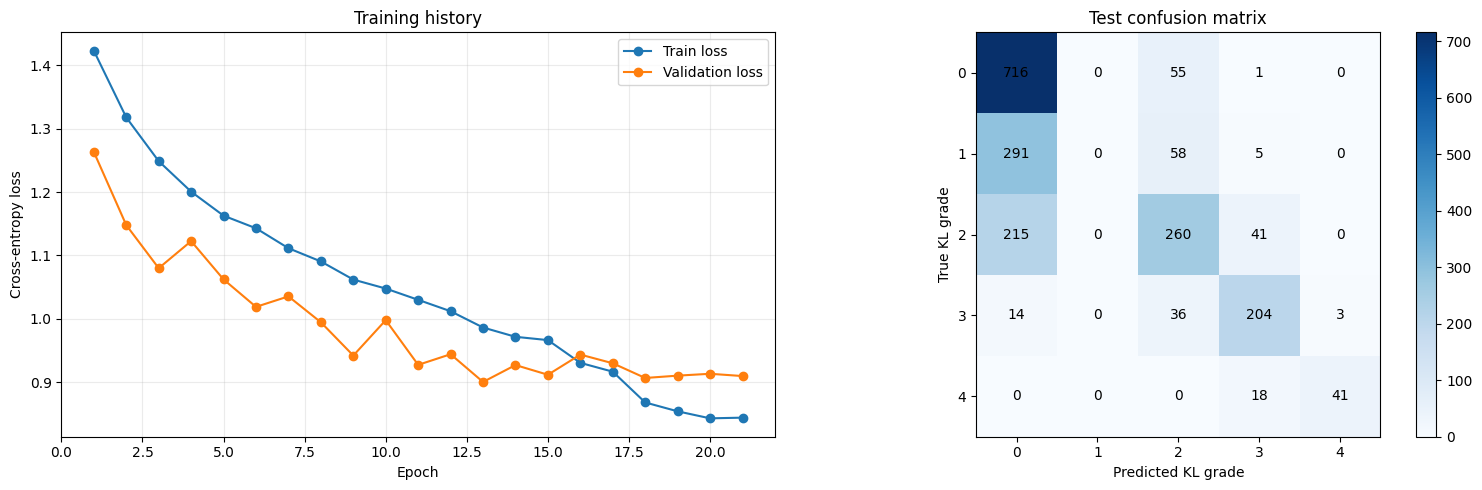

In [5]:
from IPython.display import display
from sklearn.metrics import average_precision_score, cohen_kappa_score, precision_recall_fscore_support

metric_table = pd.DataFrame([{
    'Accuracy': test_metrics['accuracy'],
    'QWK': test_metrics['qwk'],
    'Macro precision': test_metrics['macro_precision'],
    'Macro recall': test_metrics['macro_recall'],
    'Macro F1': test_metrics['macro_f1'],
    'Macro AP': test_metrics['macro_ap'],
    'Macro ROC AUC (OvR)': test_metrics['auc_ovr'],
}]).T.rename(columns={0: 'Test result'})
display(metric_table.style.format('{:.4f}'))

report_df = pd.DataFrame(classification_report(labels, predictions, labels=range(5), output_dict=True, zero_division=0)).T
print('Classification report')
display(report_df.style.format('{:.4f}'))

matrix = confusion_matrix(labels, predictions, labels=range(5))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Validation loss')
axes[0].set(title='Training history', xlabel='Epoch', ylabel='Cross-entropy loss')
axes[0].legend(); axes[0].grid(alpha=0.25)
image = axes[1].imshow(matrix, cmap='Blues')
axes[1].set(title='Test confusion matrix', xlabel='Predicted KL grade', ylabel='True KL grade', xticks=range(5), yticks=range(5))
for row in range(5):
    for column in range(5):
        axes[1].text(column, row, matrix[row, column], ha='center', va='center')
fig.colorbar(image, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.savefig(RUN_DIR / 'evaluation_dashboard.png', dpi=180, bbox_inches='tight'); plt.show()


## Grad-CAM Examples

These are predicted-class Grad-CAM overlays for one locked test image from each true KL grade. They are visual evidence only; a heatmap is not a diagnostic segmentation.


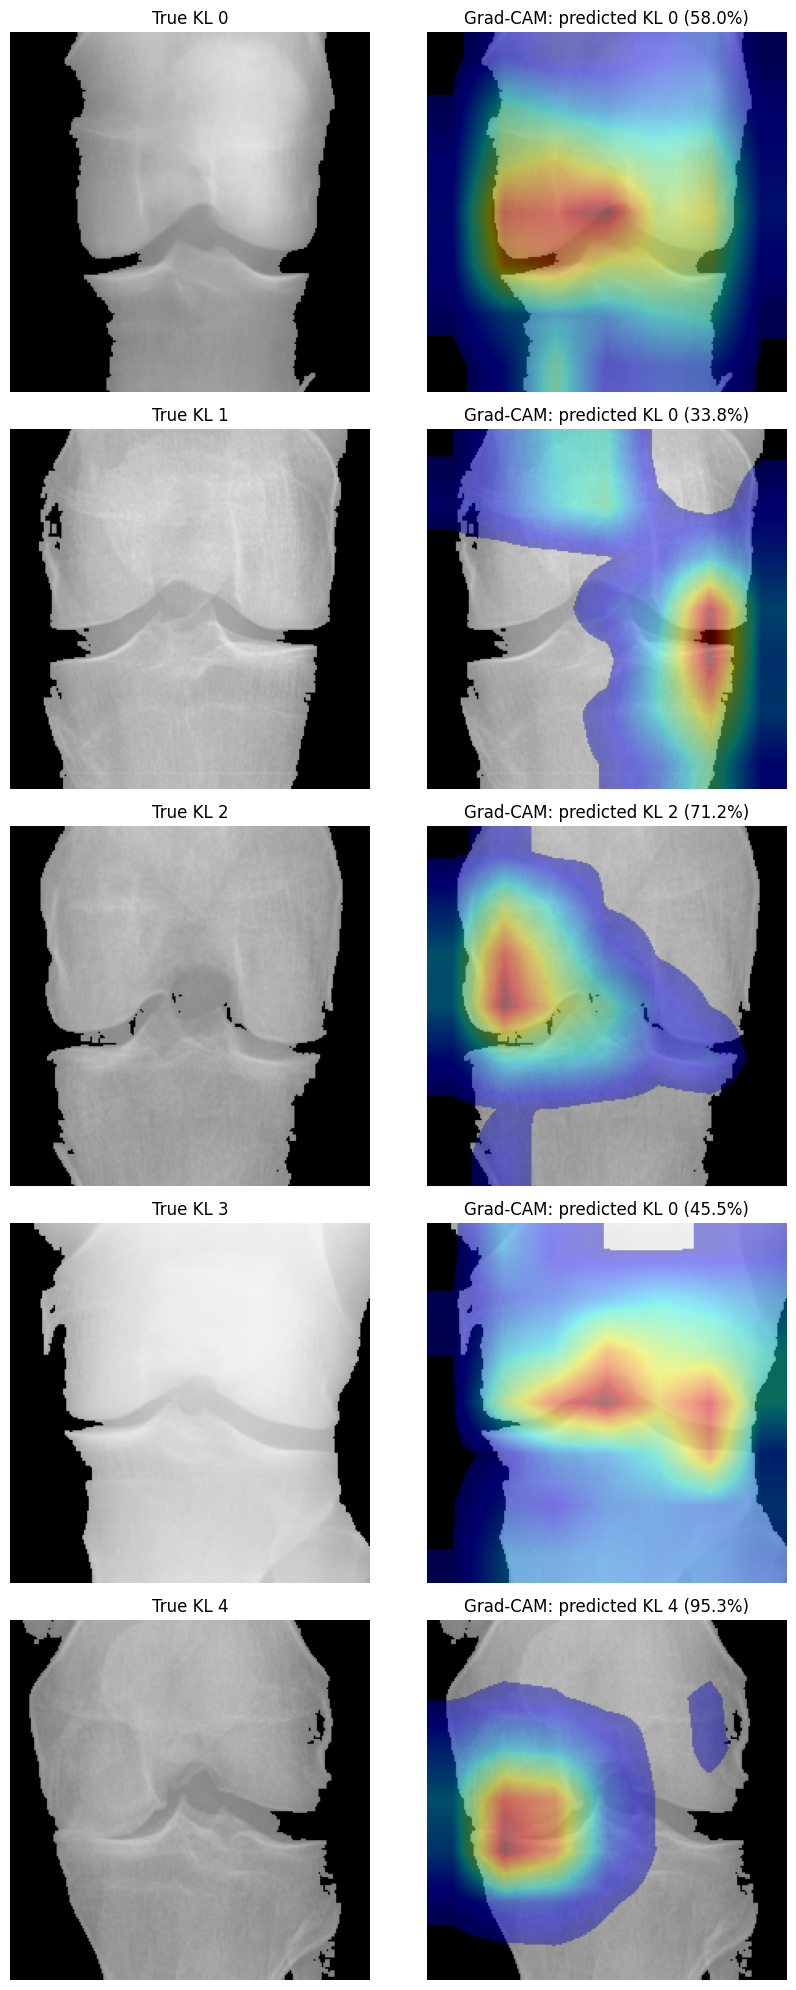

In [6]:
def dense_gradcam(input_tensor, class_index):
    captured = {}

    def capture(_module, _inputs, output):
        captured['activation'] = output

    handle = model.backbone.features.norm5.register_forward_hook(capture)
    try:
        model.eval(); model.zero_grad(set_to_none=True)
        logits = model(input_tensor)
        activation = captured['activation']
        gradients = torch.autograd.grad(logits[0, class_index], activation)[0]
        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * activation).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(INPUT_SIZE, INPUT_SIZE), mode='bilinear', align_corners=False)[0, 0]
    finally:
        handle.remove()
    cam = cam.detach().cpu().numpy()
    return cam / cam.max() if cam.max() > 1e-8 else np.zeros_like(cam)


def show_gradcam(axis, display_image, cam, title):
    # Keep the original radiograph visible. Low CAM values are transparent instead
    # of colouring the entire background dark blue.
    visible_cam = np.ma.masked_where(cam <= 0.05, cam)
    axis.imshow(display_image, cmap='gray', vmin=0, vmax=255)
    axis.imshow(visible_cam, cmap='jet', alpha=0.42, vmin=0, vmax=1)
    axis.set_title(title); axis.axis('off')


samples = test.groupby('grade', group_keys=False).head(1).sort_values('grade')
fig, axes = plt.subplots(len(samples), 2, figsize=(9, 4 * len(samples)))
for row_index, row in enumerate(samples.itertuples()):
    original = paper_preprocess(row.path)
    tensor = eval_transform(original)[None].to(DEVICE)
    with torch.no_grad():
        logits = model(tensor); predicted = int(logits.argmax(1).item()); confidence = float(F.softmax(logits, 1)[0, predicted].item())
    cam = dense_gradcam(tensor, predicted)
    axes[row_index, 0].imshow(original, cmap='gray'); axes[row_index, 0].set_title(f'True KL {row.grade}'); axes[row_index, 0].axis('off')
    show_gradcam(axes[row_index, 1], original, cam, f'Grad-CAM: predicted KL {predicted} ({confidence:.1%})')
plt.tight_layout(); plt.savefig(RUN_DIR / 'gradcam_by_true_grade.png', dpi=180, bbox_inches='tight'); plt.show()
